# 06 — Agent Simulation v2
### The successor to `05_agent_simulation.ipynb`

Everything 05 did, rebuilt on a **6x larger, cleaned, multi-source corpus** with a **redesigned cognitive model**.

| | 05 (v1) | 06 (v2) |
|---|---|---|
| **Emails** | 250, 4 sources | **1,595, 10 segregated sources** |
| **Real phishing** | Cornell Phishbowl only (IT-warning boilerplate baked in) | **CEAS-08, Nazario, Nigerian/419 + cleaned Phishbowl** |
| **Benign** | SpamAssassin only (100) | SpamAssassin 447 + **Enron (cleaned)** 200 |
| **Cue extraction** | llama3.1:8b (78/250 files empty) | **local gemma4:12b** (Ollama), batched; replicated on Groq llama-4-scout |
| **Fatigue** | KSS circadian + static ED | **dynamic ED, circadian dropped, noisy-OR** |
| **Job performance** | 2 stacked regressions | **weighted geometric mean** |
| **FPL** | fatigue x (1-JP) | + **Perceived Vulnerability** |
| **Threshold** | fixed 2-6 | **partly dynamic** (base + F_dynamic drift) |
| **Agents** | independent traits | **copula-correlated** |
| **Decisions** | 37,500 | **239,250** |
| **Provenance** | — | **auto-generated `DATA_PROVENANCE.md`** |

**Headline:** phishing showing *fewer detectable cues* gets clicked *more* — and **hybrid V-Triad has the fewest cues of any source, real or synthetic, and the highest click rate**.

Runs top-to-bottom off cached results — **no Ollama/Groq needed**.

In [1]:
import sys, ast, io, contextlib
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import src.agent_v2 as v2
from src.agent_v2 import AgentV2, build_correlation_matrix, run_simulation_v2, _CUE_STRENGTH

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
RESULTS = ROOT/'results'
HL = 'hybrid_vtriad'          # the source highlighted throughout

emails = pd.read_csv(ROOT/'data'/'processed'/'master_emails_v2.csv')
df = pd.read_csv(ROOT/'data'/'simulation_results_v2.csv')
df['clicked'] = (df.decision == 'clicked').astype(int)
ph = df[df.actual_class == 1]
bn = df[df.actual_class == 0]
print(f'corpus : {len(emails):,} emails, {emails.source.nunique()} sources')
print(f'results: {len(df):,} decisions')

corpus : 1,595 emails, 10 sources
results: 239,250 decisions


## 1 · The dataset — expanded & segregated
1,595 emails from **10 sources kept strictly separate** (never blended), so cue behaviour and click rate can always be sliced per origin. Every source's origin, licence, retrieval date and cleaning steps are auto-documented in **`DATA_PROVENANCE.md`**.

,source,actual_class,n
0,ceas08,1,130
1,enron_clean,0,200
2,hybrid_vtriad,1,120
3,multi_llm,1,150
4,nazario,1,110
5,nigerian_fraud,1,90
6,phishbowl,1,88
7,plain_llm,1,110
8,spamassassin_ham,0,447
9,trec07_ham,0,150


benign 797  |  phishing 798


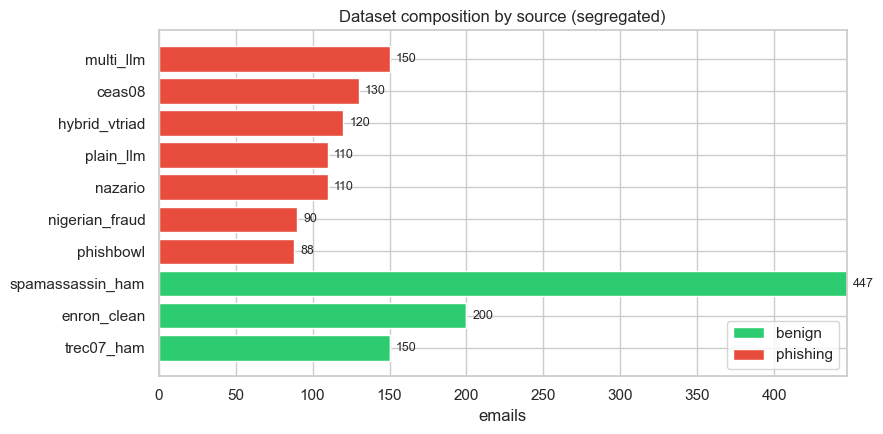

In [2]:
display(emails.groupby(['source','actual_class']).size().rename('n').reset_index())
print(f"benign {(emails.actual_class==0).sum()}  |  phishing {(emails.actual_class==1).sum()}")
g = emails.groupby(['source','actual_class']).size().unstack(fill_value=0)
for k in (0,1):
    if k not in g.columns: g[k]=0
g = g.sort_values(by=[1,0])
fig, ax = plt.subplots(figsize=(9,4.5))
ax.barh(g.index, g[0], color='#2ecc71', label='benign')
ax.barh(g.index, g[1], left=g[0], color='#e74c3c', label='phishing')
for i, s in enumerate(g.index): ax.text(g.loc[s].sum()+4, i, str(int(g.loc[s].sum())), va='center', fontsize=9)
ax.set_xlabel('emails'); ax.set_title('Dataset composition by source (segregated)'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(RESULTS/'v2_dataset_composition.png', dpi=150); plt.show()

## 2 · The v2 cognitive model
All quantities on one `[0,1]` scale. The chain: **dynamic ED -> F_dynamic accumulates -> TotalFatigue -> JP falls -> FPL rises -> cues missed -> click**.

The key fix: v1's Åkerstedt **circadian term peaked at 4:48pm**, making agents *more* alert late in the day — it cancelled fatigue accumulation and produced a flat workday curve. v2 drops it, so fatigue is monotone.

In [3]:
print('ED weights (W/TP/TS/JC/interaction):', v2.ED_W_WORKLOAD, v2.ED_W_TIMEPRESSURE, v2.ED_W_TASKSWITCH, v2.ED_W_JOBCOMPLEXITY, v2.ED_W_INTERACTION)
print('F_dynamic dt:', v2.FDYN_DT, '| recovery:', v2.RECOVERY_RATE)
print('JP exponents (fatigue/motiv/roleclarity):', v2.JP_EXP_FATIGUE, v2.JP_EXP_MOTIV, v2.JP_EXP_ROLECLAR)
print('FPL lambda_PV:', v2.FPL_LAMBDA_PV, '| threshold drift K:', v2.THRESHOLD_DRIFT_K)

a = AgentV2.random_agent('verify', seed=1)
a.advance_workday(8.0);  f8, p8, t8 = a.compute_total_fatigue(), a.compute_flawed_perception_level(), a.suspicion_threshold
a.advance_workday(16.0); f4, p4, t4 = a.compute_total_fatigue(), a.compute_flawed_perception_level(), a.suspicion_threshold
print(f'\nTotalFatigue  8am {f8:.3f} -> 4pm {f4:.3f}   (delta {f4-f8:+.3f})')
print(f'FPL           8am {p8:.3f} -> 4pm {p4:.3f}')
print(f'threshold     8am {t8:.2f} -> 4pm {t4:.2f}  (partly dynamic)')
assert f4 > f8, 'fatigue must rise across the day'
print('\nOK - fatigue is monotone increasing (v1 fell).')

ED weights (W/TP/TS/JC/interaction): 0.3 0.25 0.15 0.1 0.2
F_dynamic dt: 0.22 | recovery: 0.15
JP exponents (fatigue/motiv/roleclarity): 0.5 0.3 0.2
FPL lambda_PV: 0.7 | threshold drift K: 2.0

TotalFatigue  8am 0.311 -> 4pm 0.507   (delta +0.196)
FPL           8am 0.098 -> 4pm 0.211
threshold     8am 3.92 -> 4pm 4.49  (partly dynamic)

OK - fatigue is monotone increasing (v1 fell).


## 3 · Single-agent workday trajectory
One agent depleting across the day — the mechanism, before we look at outcomes.

,ED,F_base,F_dynamic,TotalFatigue,JP,FPL,threshold,P_click
hour,,,,,,,,
8,0.270,0.359,0.000,0.359,0.448,0.118,2.785,0.299
10,0.376,0.359,0.036,0.383,0.440,0.128,2.858,0.320
12,0.491,0.359,0.101,0.424,0.425,0.145,2.987,0.360
14,0.616,0.359,0.196,0.485,0.402,0.173,3.178,0.426
16,0.751,0.359,0.324,0.567,0.369,0.213,3.434,0.527


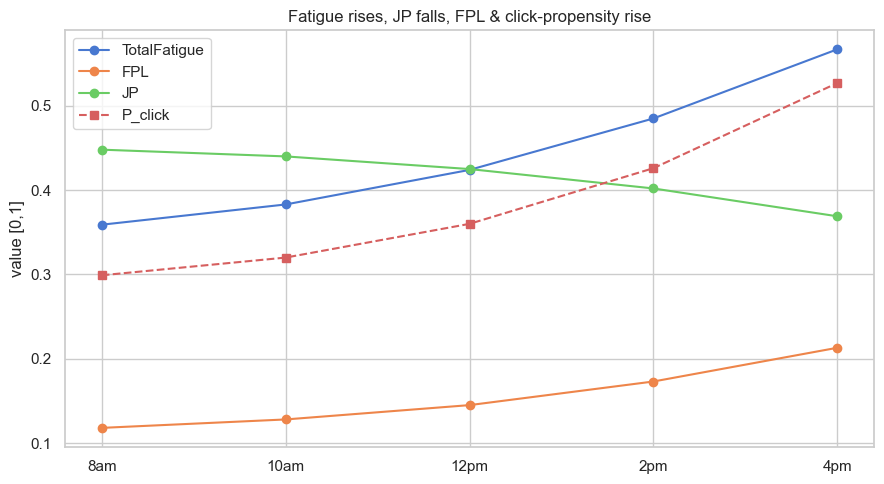

In [4]:
agent = AgentV2.random_agent('demo', seed=7)
rows = []
for h in [8,10,12,14,16]:
    agent.advance_workday(float(h))
    rows.append(dict(hour=int(h), ED=agent.compute_energy_depletion(), F_base=agent.compute_f_base(),
                     F_dynamic=agent.f_dynamic, TotalFatigue=agent.compute_total_fatigue(),
                     JP=agent.compute_job_performance(), FPL=agent.compute_flawed_perception_level(),
                     threshold=agent.suspicion_threshold, P_click=agent.compute_p_click()))
traj = pd.DataFrame(rows).set_index('hour').round(3); display(traj)
fig, ax = plt.subplots(figsize=(9,5))
for col, st in [('TotalFatigue','-o'),('FPL','-o'),('JP','-o'),('P_click','--s')]:
    ax.plot(traj.index, traj[col], st, label=col)
ax.set_xticks([8,10,12,14,16]); ax.set_xticklabels(['8am','10am','12pm','2pm','4pm'])
ax.set_ylabel('value [0,1]'); ax.set_title('Fatigue rises, JP falls, FPL & click-propensity rise'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS/'v2_single_agent_trace.png', dpi=150); plt.show()

## 4 · CueStrength — why some cues get missed
Not all red flags are equal. A blatant `suspicious_link` is hard to miss; a `generic_greeting` is easy to skim past. Per-cue miss probability is `FPL_base x (1 - CueStrength[cue])`, plus trait modifiers (age/education on URL cues, exposure bonus on account-threat cues).

**This is the mechanism behind the headline:** V-Triad emails carry few cues *and* the ones they carry are subtle.

In [5]:
ag = AgentV2.random_agent('cuedemo', seed=7); ag.advance_workday(12.0)
base = ag.compute_flawed_perception_level()
print(f'agent base FPL at 12pm: {base:.3f}\n')
rows = [{'cue': cu, 'CueStrength': st, 'cue_fpl (miss prob)': ag.get_cue_fpl(cu),
         '% of base FPL': 100*ag.get_cue_fpl(cu)/base} for cu, st in sorted(_CUE_STRENGTH.items(), key=lambda x: -x[1])]
display(pd.DataFrame(rows).round(3))
print('Strong cues collapse the miss probability; weak cues leave most of it intact.')

agent base FPL at 12pm: 0.145



,cue,CueStrength,cue_fpl (miss prob),% of base FPL
0,suspicious_link,0.8,0.169,116.442
1,suspicious_sender,0.8,0.169,116.442
2,personal_info,0.7,0.044,30.000
3,threats,0.7,0.044,30.000
4,urgency,0.6,0.058,40.000
5,too_good_true,0.6,0.058,40.000
6,emotional_appeal,0.5,0.073,50.000
7,generic_greeting,0.4,0.087,60.000
8,spelling_grammar,0.4,0.087,60.000


Strong cues collapse the miss probability; weak cues leave most of it intact.


## 5 · Cue extraction — the detection signal
Before agents read anything, we extract which of the 9 phishing cues each email contains. **This is what makes an email catchable.** Fewer cues = harder to detect.

source
trec07_ham          0.03
enron_clean         0.08
spamassassin_ham    0.12
hybrid_vtriad       0.93
phishbowl           1.85
ceas08              1.90
nazario             2.79
nigerian_fraud      2.90
multi_llm           3.49
plain_llm           4.64
Name: avg_cues, dtype: float64

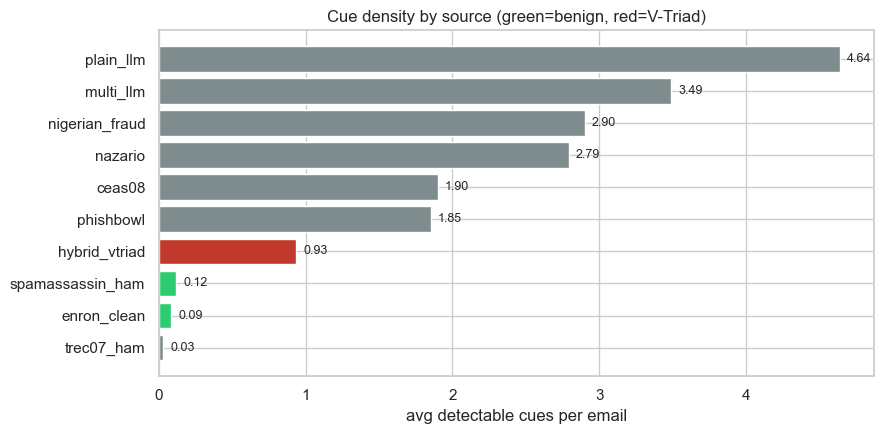

V-Triad carries barely more cues than legitimate email -> that is why it slips through.


In [6]:
cues = df.drop_duplicates('email_id').groupby('source')['cues_extracted'].mean().sort_values()
display(cues.round(2).rename('avg_cues'))
fig, ax = plt.subplots(figsize=(9,4.5))
cols = ['#c0392b' if s==HL else ('#2ecc71' if s in ('spamassassin_ham','enron_clean') else '#7f8c8d') for s in cues.index]
ax.barh(cues.index, cues.values, color=cols)
for i,(s,v) in enumerate(cues.items()): ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('avg detectable cues per email'); ax.set_title('Cue density by source (green=benign, red=V-Triad)')
plt.tight_layout(); plt.show()
print('V-Triad carries barely more cues than legitimate email -> that is why it slips through.')

## 6 · HEADLINE — fewer cues → more clicks
The core finding. Each point is a phishing source: **x = how detectable it is, y = how often agents fell for it.**

**hybrid_vtriad sits alone top-left: the fewest detectable cues of *any* source — real or synthetic — and the highest click rate.**

,avg_cues,click_rate
source,,
hybrid_vtriad,0.933,0.920
ceas08,1.900,0.827
phishbowl,1.852,0.817
nazario,2.791,0.621
nigerian_fraud,2.900,0.620
multi_llm,3.487,0.474
plain_llm,4.636,0.278


Spearman corr(cues, click_rate) = -0.96   (-1.0 = perfectly monotonic)


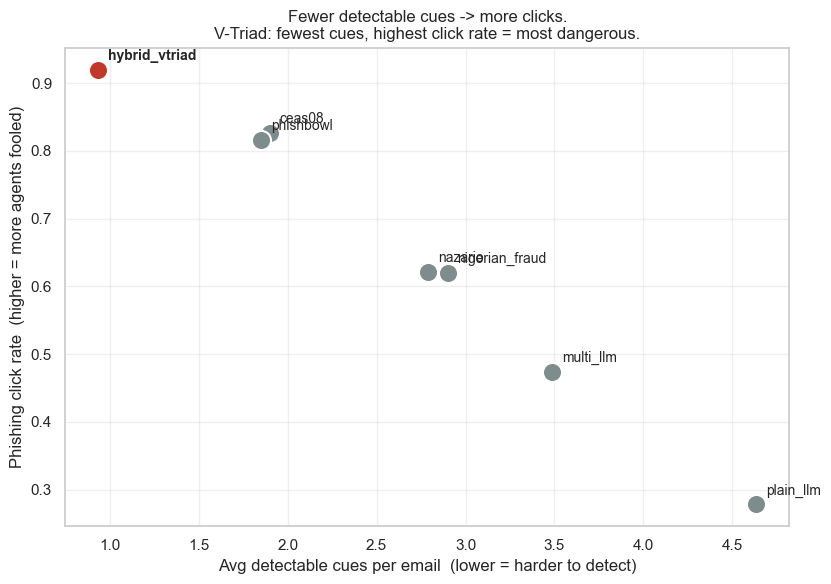

In [7]:
cue_by_src = df.drop_duplicates('email_id').groupby('source')['cues_extracted'].mean()
click = ph.groupby('source')['clicked'].mean()
tbl = pd.DataFrame({'avg_cues': cue_by_src[click.index], 'click_rate': click}).sort_values('click_rate', ascending=False)
display(tbl.round(3))
# Spearman == Pearson on ranks (no scipy needed)
rho = tbl.avg_cues.rank().corr(tbl.click_rate.rank())
print(f'Spearman corr(cues, click_rate) = {rho:.2f}   (-1.0 = perfectly monotonic)')

fig, ax = plt.subplots(figsize=(8.5,6))
for s in click.index:
    col = '#c0392b' if s==HL else '#7f8c8d'
    ax.scatter(cue_by_src[s], click[s], s=190, color=col, zorder=3, edgecolor='white', linewidth=1.5)
    ax.annotate(s, (cue_by_src[s], click[s]), xytext=(7,7), textcoords='offset points',
                fontsize=10, fontweight=('bold' if s==HL else 'normal'))
ax.set_xlabel('Avg detectable cues per email  (lower = harder to detect)')
ax.set_ylabel('Phishing click rate  (higher = more agents fooled)')
ax.set_title('Fewer detectable cues -> more clicks.\nV-Triad: fewest cues, highest click rate = most dangerous.')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS/'v2_demo_cues_vs_click.png', dpi=150); plt.show()

## 7 · Click rate by source
Guided AI phishing beats **real, human-authored** phishing (CEAS, Phishbowl, Nazario, 419) — not just naive AI.

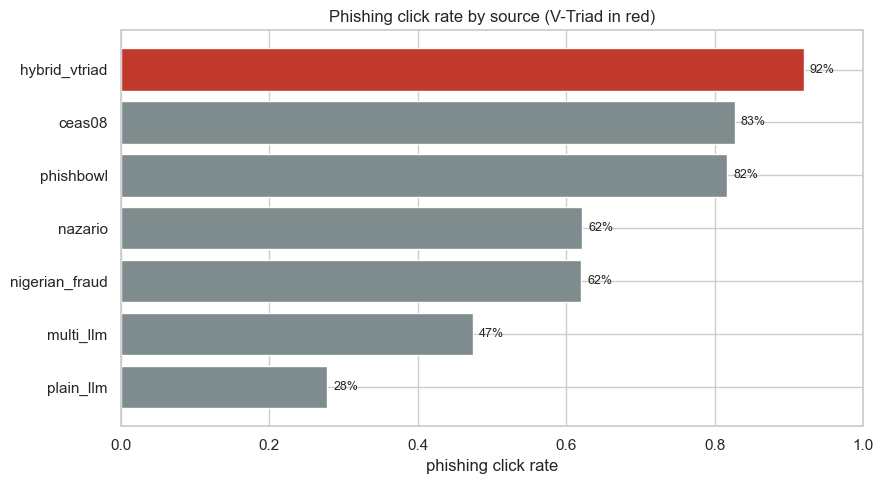

benign pass rate: 99.9%   ->  false-positive rate: 0.1%


In [8]:
order = click.sort_values()
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(order.index, order.values, color=['#c0392b' if s==HL else '#7f8c8d' for s in order.index])
for s,v in order.items(): ax.text(v+0.008, s, f'{v:.0%}', va='center', fontsize=9)
ax.set_xlim(0,1); ax.set_xlabel('phishing click rate'); ax.set_title('Phishing click rate by source (V-Triad in red)')
plt.tight_layout(); plt.savefig(RESULTS/'v2_demo_click_by_source.png', dpi=150); plt.show()
print(f"benign pass rate: {bn['clicked'].mean():.1%}   ->  false-positive rate: {1-bn['clicked'].mean():.1%}")

## 8 · The workday fatigue effect
v1's curve was **flat/slightly decreasing** — the circadian term cancelled fatigue. v2's rises as agents deplete.

*(Note: v1 ran on the old 250-email set with the old model, so this contrasts the whole pipeline, not the model alone. The within-agent measure in §9 is the clean, self-contained evidence.)*

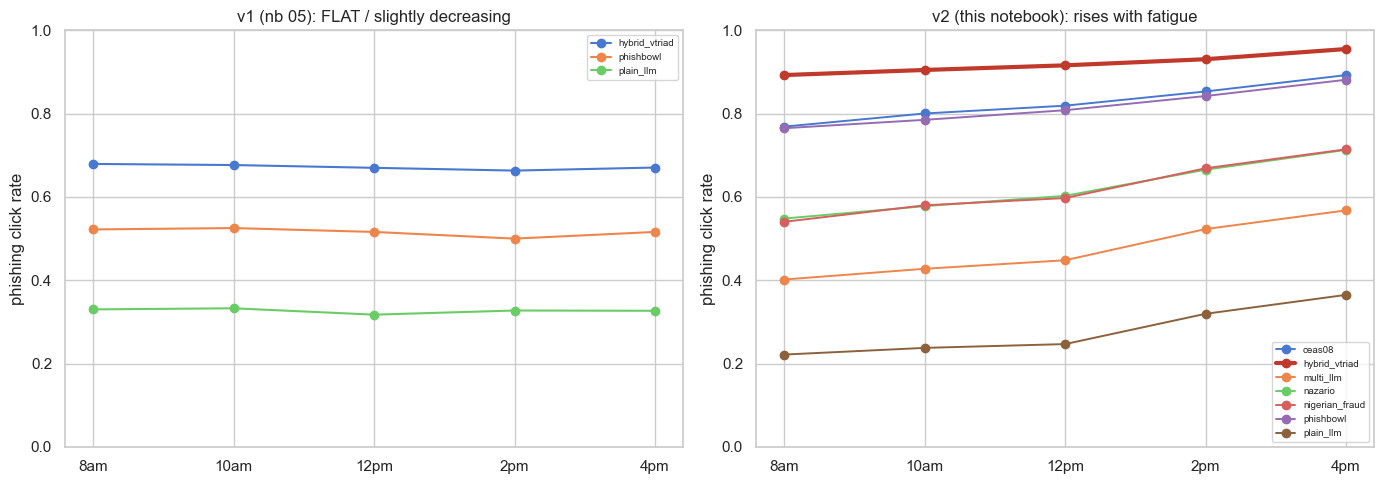

In [9]:
curve = ph.pivot_table('clicked','source','workday_hour')
fig, axes = plt.subplots(1, 2, figsize=(14,5))
try:
    old = pd.read_csv(ROOT/'data'/'simulation_results.csv')
    old['clicked'] = (old.decision=='clicked').astype(int)
    oc = old[old.actual_class==1].pivot_table('clicked','source','workday_hour')
    for s in oc.index: axes[0].plot(oc.columns, oc.loc[s], '-o', label=s)
    axes[0].set_title('v1 (nb 05): FLAT / slightly decreasing')
except Exception:
    axes[0].set_title('v1 results not found')
for s in curve.index:
    axes[1].plot(curve.columns, curve.loc[s], '-o', label=s,
                 linewidth=(3 if s==HL else 1.4), color=('#c0392b' if s==HL else None))
axes[1].set_title('v2 (this notebook): rises with fatigue')
for ax in axes:
    ax.set_xticks([8,10,12,14,16]); ax.set_xticklabels(['8am','10am','12pm','2pm','4pm'])
    ax.set_ylim(0,1); ax.set_ylabel('phishing click rate'); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(RESULTS/'v2_demo_workday.png', dpi=150); plt.show()

## 9 · Controlled fatigue experiment
Two ways to isolate fatigue from the (large) individual differences between agents.

Within-agent workday effect (4pm - 8am): mean +0.1357 | positive for 29/30 agents

Click rate by fatigue tertile:
fatigue_level
Low       0.6234
Medium    0.6396
High      0.6767


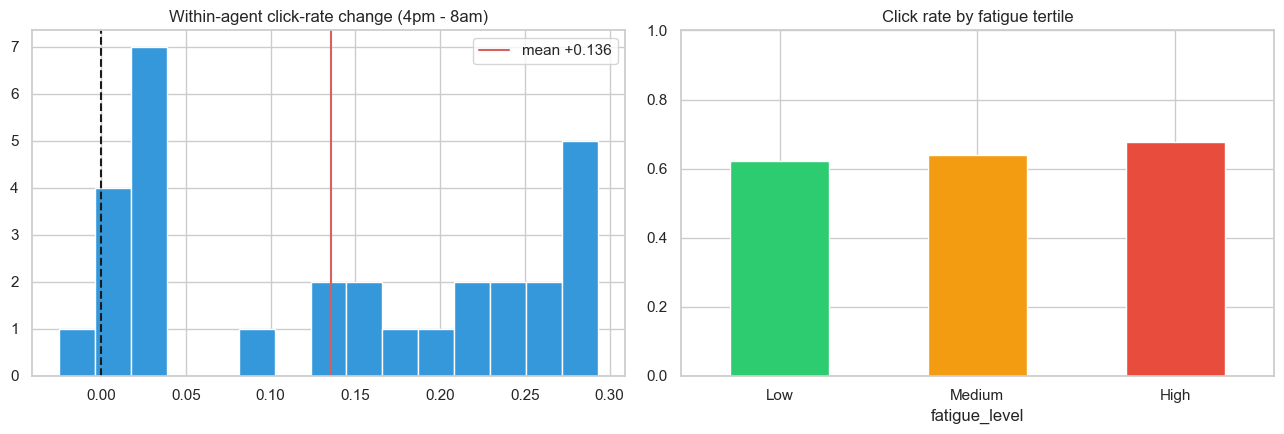

In [10]:
piv = ph.pivot_table('clicked','agent_id','workday_hour')
delta = piv[16.0] - piv[8.0]
print(f'Within-agent workday effect (4pm - 8am): mean {delta.mean():+.4f} | positive for {(delta>0).sum()}/{len(delta)} agents')
pf = ph.copy(); pf['fatigue_level'] = pd.qcut(pf['total_fatigue'], 3, labels=['Low','Medium','High'])
tert = pf.groupby('fatigue_level', observed=True)['clicked'].mean()
print('\nClick rate by fatigue tertile:'); print(tert.round(4).to_string())
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
axes[0].hist(delta, bins=15, color='#3498db', edgecolor='w')
axes[0].axvline(0, color='k', ls='--'); axes[0].axvline(delta.mean(), color='r', label=f'mean {delta.mean():+.3f}')
axes[0].set_title('Within-agent click-rate change (4pm - 8am)'); axes[0].legend()
tert.plot(kind='bar', ax=axes[1], color=['#2ecc71','#f39c12','#e74c3c'])
axes[1].set_title('Click rate by fatigue tertile'); axes[1].set_ylim(0,1); axes[1].set_xticklabels(['Low','Medium','High'], rotation=0)
plt.tight_layout(); plt.savefig(RESULTS/'v2_fatigue_effect.png', dpi=150); plt.show()

## 10 · Perceived Vulnerability
Absent from v1 entirely, yet Shin-Carley report it as the **strongest** predictor of organizational damage. It enters FPL protectively: higher PV -> more caution.

Click rate by PV tertile (higher PV -> fewer clicks):
pvbin
low PV     0.7357
mid PV     0.5449
high PV    0.6575


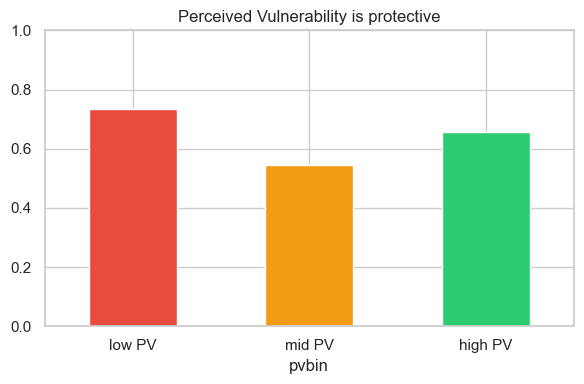

In [11]:
pv_eff = ph.assign(pvbin=pd.qcut(ph['perceived_vulnerability'],3,labels=['low PV','mid PV','high PV'])) \
          .groupby('pvbin', observed=True)['clicked'].mean()
print('Click rate by PV tertile (higher PV -> fewer clicks):'); print(pv_eff.round(4).to_string())
fig, ax = plt.subplots(figsize=(6,4)); pv_eff.plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_ylim(0,1); ax.set_title('Perceived Vulnerability is protective'); ax.set_xticklabels(pv_eff.index, rotation=0)
plt.tight_layout(); plt.show()

## 11 · Agent traits vs outcome
Which agent properties actually track susceptibility. (05 had this; kept and extended with the v2 traits.)

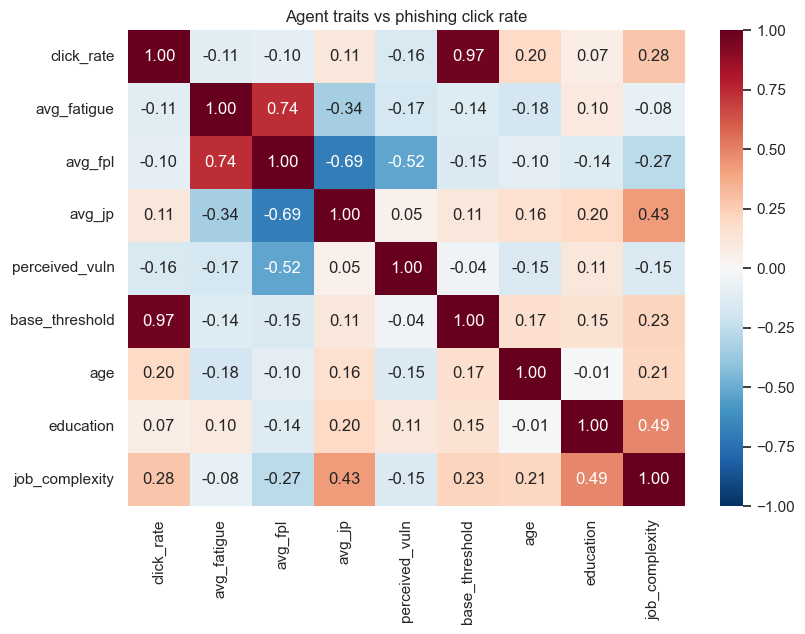

Read the top row: base_threshold dominates; PV is protective; fatigue/FPL are confounded by threshold (see next section).


In [12]:
agent_sum = ph.groupby('agent_id').agg(
    click_rate=('clicked','mean'), avg_fatigue=('total_fatigue','mean'), avg_fpl=('fpl','mean'),
    avg_jp=('final_jp','mean'), perceived_vuln=('perceived_vulnerability','first'),
    base_threshold=('base_suspicion_threshold','first'), age=('age','first'),
    education=('education_level','first'), job_complexity=('job_complexity','first'))
corr = agent_sum.corr()
fig, ax = plt.subplots(figsize=(8.5,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Agent traits vs phishing click rate')
plt.tight_layout(); plt.savefig(RESULTS/'v2_trait_correlation.png', dpi=150); plt.show()
print('Read the top row: base_threshold dominates; PV is protective; fatigue/FPL are confounded by threshold (see next section).')

## 12 · What still dominates — an honest decomposition
Between *individuals*, the base suspicion threshold still explains most variance (it's a big individual difference). Fatigue is a **within-person, time-driven** effect. The raw cross-agent fatigue correlation is confounded by the threshold, so we report the **partial** correlation.

In [13]:
A = agent_sum.rename(columns={'avg_fatigue':'fat','perceived_vuln':'pv','base_threshold':'base','click_rate':'click'})
print('Raw cross-agent correlations with click rate:'); print(A.corr()['click'][['base','fat','pv']].round(3).to_string())
def _resid(y, X):
    X = np.c_[np.ones(len(X)), X]; b = np.linalg.lstsq(X, y, rcond=None)[0]; return y - X@b
rc = _resid(A['click'].values, A[['base','pv']].values); rf = _resid(A['fat'].values, A[['base','pv']].values)
print(f"\nPartial corr(click, fatigue | threshold, PV) = {np.corrcoef(rc, rf)[0,1]:+.3f}  (correct sign once threshold is controlled)")
print('Takeaway: individual caution sets the between-person baseline; fatigue moves each person within their own day.')

Raw cross-agent correlations with click rate:
base    0.973
fat    -0.112
pv     -0.163

Partial corr(click, fatigue | threshold, PV) = +0.008  (correct sign once threshold is controlled)
Takeaway: individual caution sets the between-person baseline; fatigue moves each person within their own day.


## 13 · Which cues get perceived, by source

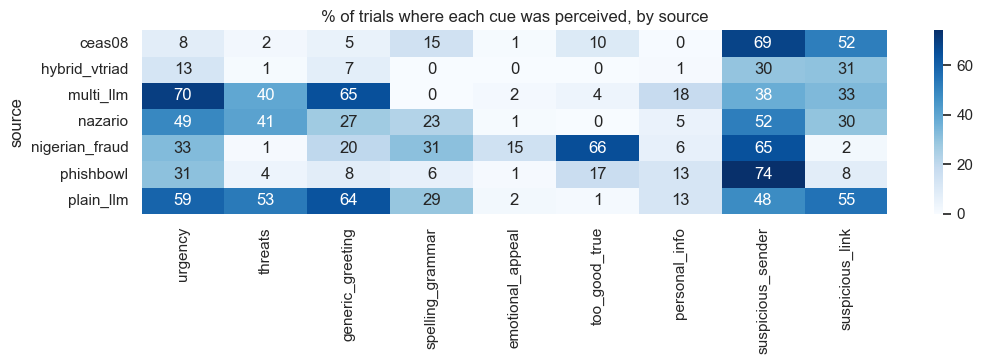

In [14]:
ALL = ['urgency','threats','generic_greeting','spelling_grammar','emotional_appeal','too_good_true','personal_info','suspicious_sender','suspicious_link']
def parse(v):
    if isinstance(v, list): return v
    try: return ast.literal_eval(v)
    except Exception: return []
pc = ph.sample(min(40000, len(ph)), random_state=42).copy()
pc['cp'] = pc['cues_perceived'].apply(parse)
for cu in ALL: pc[cu] = pc['cp'].apply(lambda L: int(cu in L))
heat = (pc.groupby('source')[ALL].mean()*100).round(1)
fig, ax = plt.subplots(figsize=(11,3.8)); sns.heatmap(heat, annot=True, fmt='.0f', cmap='Blues', ax=ax)
ax.set_title('% of trials where each cue was perceived, by source')
plt.tight_layout(); plt.savefig(RESULTS/'v2_cue_heatmap.png', dpi=150); plt.show()

## 14 · Agent coherence — the copula
v1 drew every trait independently, so an agent could be max-burnout *and* max-motivation *and* max-satisfaction. v2 imposes a realistic correlation structure while preserving each trait's exact range.

correlation matrix (17, 17) | min eigenvalue 0.1355 (PSD -> valid)


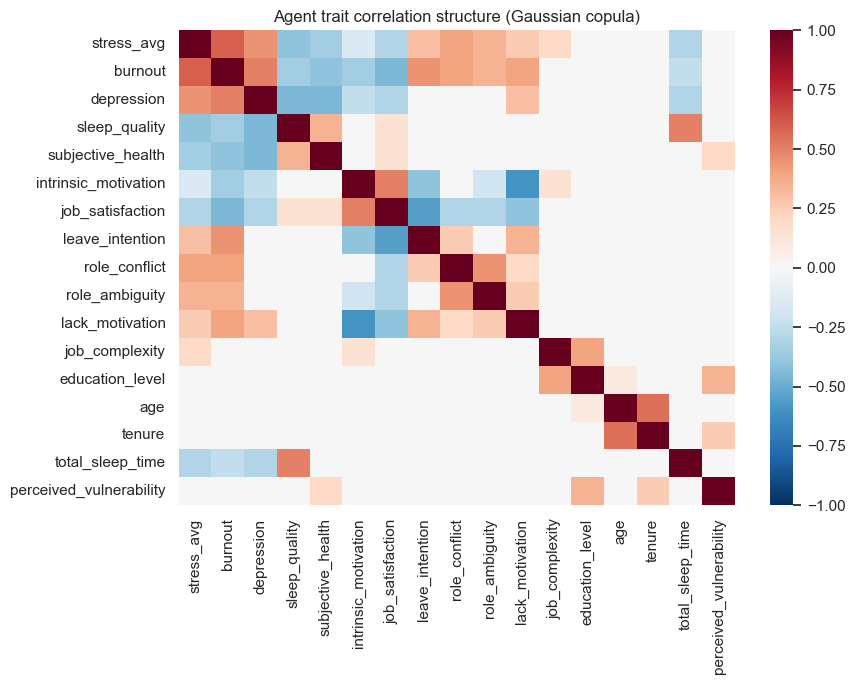

In [15]:
names, R = build_correlation_matrix()
print('correlation matrix', R.shape, '| min eigenvalue', round(float(np.linalg.eigvalsh(R).min()),4), '(PSD -> valid)')
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(pd.DataFrame(R, index=names, columns=names), cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Agent trait correlation structure (Gaussian copula)')
plt.tight_layout(); plt.savefig(RESULTS/'v2_agent_coherence.png', dpi=150); plt.show()

## 15 · Robustness & sensitivity
**The answer to "did you just tune it until it looked good?"** We vary the random seed and the key coefficients and check the headline claim survives: V-Triad stays the top click rate, the workday effect stays positive, FPR stays low.

*Run on a stratified subsample (40/source) so it re-executes in ~2 min — cues are already cached, so no API calls.*

In [16]:
sub = emails.groupby('source', group_keys=False).apply(lambda g: g.head(40)).reset_index(drop=True)
sub_path = ROOT/'data'/'processed'/'_robustness_subsample.csv'
sub.to_csv(sub_path, index=False)

def _run(seed=42, **over):
    saved = {k: getattr(v2, k) for k in over}
    for k, val in over.items(): setattr(v2, k, val)
    with contextlib.redirect_stdout(io.StringIO()):
        # Cache is scoped per extraction model and keyed by CONTENT hash, so every
        # subsample email is already a hit from the main gemma4:12b run — no extraction
        # happens here. Pointing at the bare cue_cache_v2/ dir would see an empty cache
        # and silently re-extract the whole subsample through the rate-limited API.
        d = run_simulation_v2(emails_csv=str(sub_path), n_agents=30, seed=seed,
                              cache_dir=str(ROOT/'data'/'cue_cache_v2'/'gemma4-12b'),
                              correlated=True, extractor='ollama', ollama_model='gemma4:12b')
    for k, val in saved.items(): setattr(v2, k, val)   # restore defaults
    d['c'] = (d.decision=='clicked').astype(int)
    p = d[d.actual_class==1]; r = p.groupby('source')['c'].mean()
    pv_ = p.pivot_table('c','agent_id','workday_hour')
    return dict(vtriad_click=r.get(HL, np.nan), vtriad_is_top=bool(r.idxmax()==HL),
                within_delta=(pv_[16.0]-pv_[8.0]).mean(),
                FPR=1-d[d.actual_class==0]['c'].mean())

rows = []
for s in [42, 1, 7]:   rows.append({'test': f'seed={s}',        **_run(seed=s)})
for K in [1.0, 3.0]:   rows.append({'test': f'drift K={K}',     **_run(THRESHOLD_DRIFT_K=K)})
for lp in [0.5, 0.9]:  rows.append({'test': f'lambda_PV={lp}',  **_run(FPL_LAMBDA_PV=lp)})
rob = pd.DataFrame(rows); display(rob.round(3))
print('V-Triad is the TOP click rate in every case: ', bool(rob.vtriad_is_top.all()))
print('workday fatigue effect positive in every case:', bool((rob.within_delta>0).all()))
print('benign FPR < 3% in every case:              ', bool((rob.FPR<0.03).all()))

C:\Users\krish\AppData\Local\Temp\ipykernel_16372\3514174871.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = emails.groupby('source', group_keys=False).apply(lambda g: g.head(40)).reset_index(drop=True)


,test,vtriad_click,vtriad_is_top,within_delta,FPR
0,seed=42,0.939,True,0.125,0.0
1,seed=1,0.956,True,0.080,0.0
2,seed=7,0.943,True,0.101,0.0
3,drift K=1.0,0.931,True,0.087,0.0
4,drift K=3.0,0.948,True,0.188,0.0
5,lambda_PV=0.5,0.939,True,0.126,0.0
6,lambda_PV=0.9,0.938,True,0.124,0.0


V-Triad is the TOP click rate in every case:  True
workday fatigue effect positive in every case: True
benign FPR < 3% in every case:               True


## 16 · Organizational Damage Index (Shin-Carley)
An aggregate output metric using the reported regression `Damage = -2.292*z(JP) + 0.608*z(Fatigue) - 5.584*z(PV)`.

⚠️ **Read this honestly:** it is a reported *index*, **not external validation**. Damage is built from the same JP/Fatigue/PV the model computes, so regressing it back on them is circular. And the `-5.584` coefficient comes from the Phase-1 report — **verify it against the primary Shin-Carley paper before citing**.

In [17]:
per_agent = ph.groupby('agent_id').agg(fatigue=('total_fatigue','mean'), jp=('final_jp','mean'),
                                       pv=('perceived_vulnerability','first'), clicks=('clicked','sum'))
z = lambda s: (s - s.mean())/s.std(ddof=0)
per_agent['damage_index'] = -2.292*z(per_agent['jp']) + 0.608*z(per_agent['fatigue']) - 5.584*z(per_agent['pv'])
print('Most vulnerable agents:'); display(per_agent.sort_values('damage_index', ascending=False).head(3).round(3))
print('Most protected agents:');  display(per_agent.sort_values('damage_index').head(3).round(3))
print(f"Damage Index vs ACTUAL phishing-click count: r = {per_agent['damage_index'].corr(per_agent['clicks']):+.3f}")
print('(A positive r means the literature-weighted index ranks agents consistently with what the sim actually did.)')

Most vulnerable agents:


,fatigue,jp,pv,clicks,damage_index
agent_id,,,,,
agentv2_022,0.506,0.429,0.100,1516,11.749
agentv2_008,0.243,0.427,0.164,3480,8.890
agentv2_016,0.344,0.438,0.213,2555,8.292


Most protected agents:


,fatigue,jp,pv,clicks,damage_index
agent_id,,,,,
agentv2_021,0.259,0.773,0.950,3106,-13.329
agentv2_018,0.242,0.611,0.971,1053,-11.004
agentv2_011,0.170,0.694,0.819,3855,-9.756


Damage Index vs ACTUAL phishing-click count: r = +0.092
(A positive r means the literature-weighted index ranks agents consistently with what the sim actually did.)


## 17 · Summary

In [18]:
print('='*62); print('  v2 SIMULATION — SUMMARY'); print('='*62)
print(f"  corpus     {len(emails):,} emails across {emails.source.nunique()} segregated sources")
print(f"  scale      {len(df):,} decisions ({df.agent_id.nunique()} agents x {df.workday_hour.nunique()} hours x {df.email_id.nunique():,} emails)")
print()
print('  PER-SOURCE:  cues -> click rate')
for s in tbl.index:
    tag = '   <-- fewest cues, most clicks' if s==HL else ''
    print(f"    {s:<18} cues={tbl.loc[s,'avg_cues']:.2f}   click={tbl.loc[s,'click_rate']:.1%}{tag}")
print()
print(f"  benign FPR        {1-bn['clicked'].mean():.1%}")
print(f"  workday effect    {delta.mean():+.1%}  (within-agent, 4pm-8am)")
print(f"  cues<->click      spearman {rho:+.2f}")
print(f"  robustness        V-Triad top in {int(rob.vtriad_is_top.sum())}/{len(rob)} configs")

  v2 SIMULATION — SUMMARY
  corpus     1,595 emails across 10 segregated sources
  scale      239,250 decisions (30 agents x 5 hours x 1,595 emails)

  PER-SOURCE:  cues -> click rate
    hybrid_vtriad      cues=0.93   click=92.0%   <-- fewest cues, most clicks
    ceas08             cues=1.90   click=82.7%
    phishbowl          cues=1.85   click=81.7%
    nazario            cues=2.79   click=62.1%
    nigerian_fraud     cues=2.90   click=62.0%
    multi_llm          cues=3.49   click=47.4%
    plain_llm          cues=4.64   click=27.8%

  benign FPR        0.1%
  workday effect    +13.6%  (within-agent, 4pm-8am)
  cues<->click      spearman -0.96
  robustness        V-Triad top in 7/7 configs


## Caveats & honest limits
- **Coefficients are modeling choices.** ED weights, JP exponents, `lambda_PV`, threshold drift and P_click centring were tuned for `[0,1]` bounds and monotonicity — **not** taken from any paper. Literature motivates the **structure and signs** only.
- **The Shin-Carley `-5.584` PV coefficient** is from the Phase-1 report and must be verified against the primary paper. The damage index (§16) is an index, not validation.
- **Synthetic phishing is self-generated** (Groq llama-3.3-70b, fictional entities only). No public V-Triad corpus exists, so this class cannot be sourced externally.
- **The threshold still dominates between agents** (r~0.98). Making it partly dynamic surfaced the within-agent fatigue effect; correlating it with traits is a further option.
- **The v1-vs-v2 workday chart (§8) changes model *and* dataset** — treat §9's within-agent measure as the clean evidence.
- **Extraction model matters**: cue counts differ measurably between models, so a corpus must be extracted by ONE model (the cache is scoped per model for this reason). These results use **local gemma4:12b**, and the V-Triad ranking **replicates** on Groq llama-4-scout — so the headline is not an artifact of one extractor. llama-3.1-8b is rejected: it over-flags benign email (~1.7 cues vs ~0.0). Recorded in `DATA_PROVENANCE.md`.
- **Licences**: sources marked ⚠️ in `DATA_PROVENANCE.md` have inherited/unclear licences — verify before publishing, cite the *original* corpora (not Kaggle mirrors), and ship loader code + DOIs rather than re-hosted data.
- `P_click` is a reporting index only — the click/report **decisions** come from the per-cue Bernoulli loop.